<a href="https://colab.research.google.com/github/wajdalkhaldi/Image-Processing/blob/main/lab3/Lab3_Image_Mnupilations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geometric & Intensity Transformations


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [3]:
# Import the library
from PIL import Image, ImageOps
import numpy as np


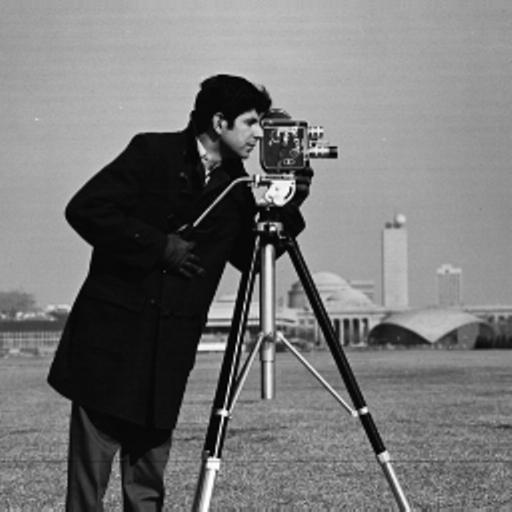

In [8]:
# ── Load image ────────────────────────────
# Grayscale (mode 'L') so the intensity transforms later work on a single channel
img = Image.open("cameraman.png").convert("L")
img


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [9]:
# Get the size of the image
width, height = img.size
print("Original size (w, h):", (width, height))

# scaling factors
cx, cy = 2, 2   # double along both axes


Original size (w, h): (512, 512)


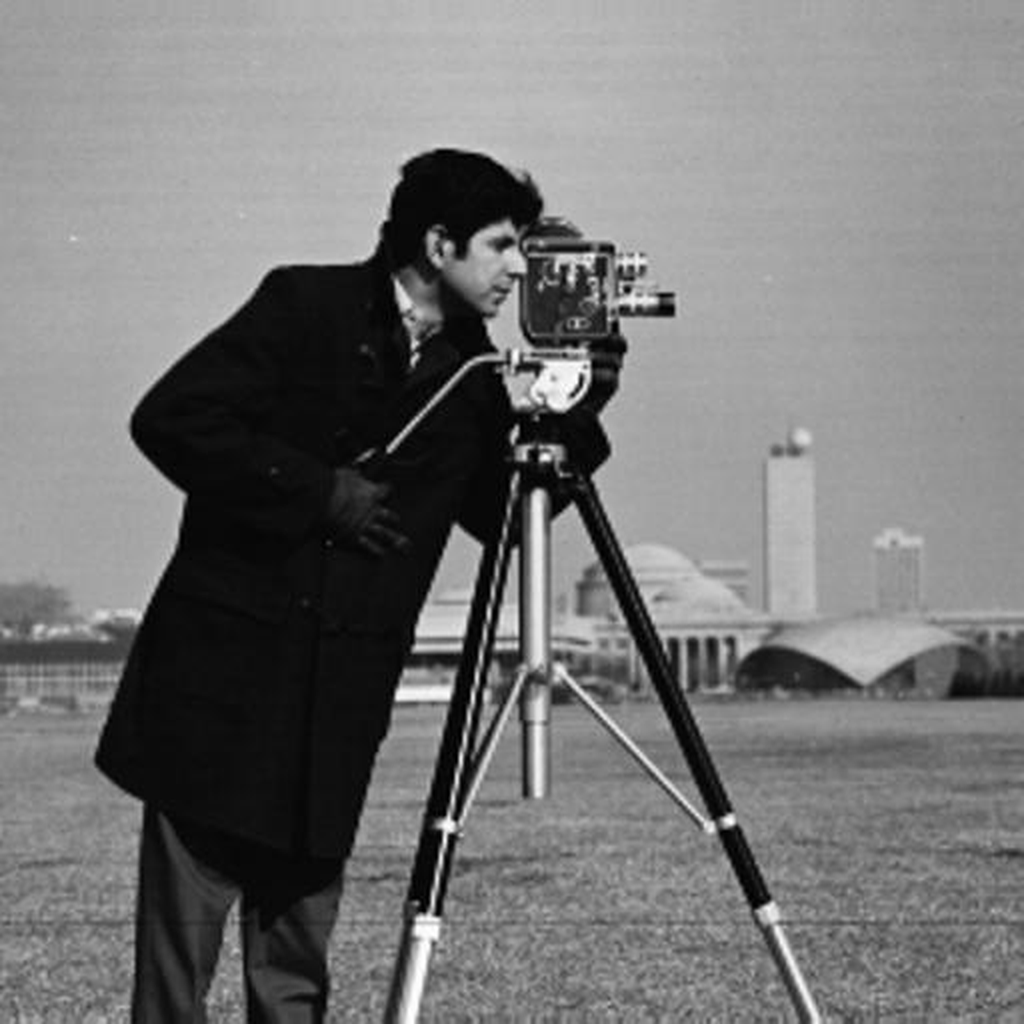

In [10]:
# ── 1. Increase size (scale ×2) ────────────
# Resize the image using PIL's built-in method
new_size = (width * cx, height * cy)

# LANCZOS is a high-quality resampling filter (good for upscaling)
scaled_img = img.resize(new_size, Image.LANCZOS)
scaled_img


In [11]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:  ", scaled_img.size)


Original size: (512, 512)
Scaled size:   (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [12]:
# Non-uniform scale (cx=2, cy=1) -> stretch horizontally only
cx, cy = 2, 1
new_size_nu = (width * cx, height * cy)
print("Non-uniform target size:", new_size_nu)


Non-uniform target size: (1024, 512)


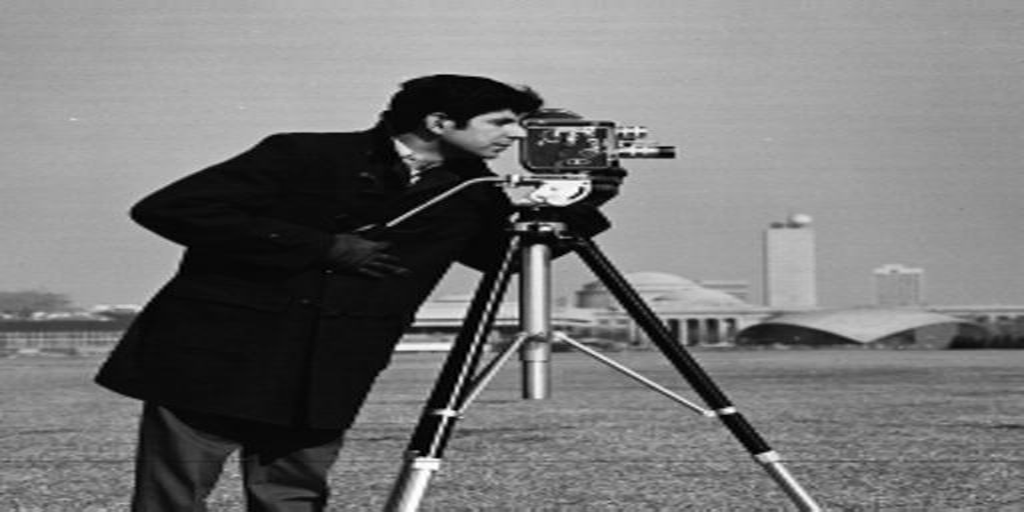

In [13]:
# Resize with the non-uniform factors (width doubles, height stays)
stretched_img = img.resize(new_size_nu, Image.LANCZOS)
stretched_img


In [14]:
# Save the horizontally-stretched image
stretched_img.save("task1_1b_stretched.jpg")

print("Original size:   ", img.size)
print("Stretched size:  ", stretched_img.size)


Original size:    (512, 512)
Stretched size:   (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size:  (700, 700)


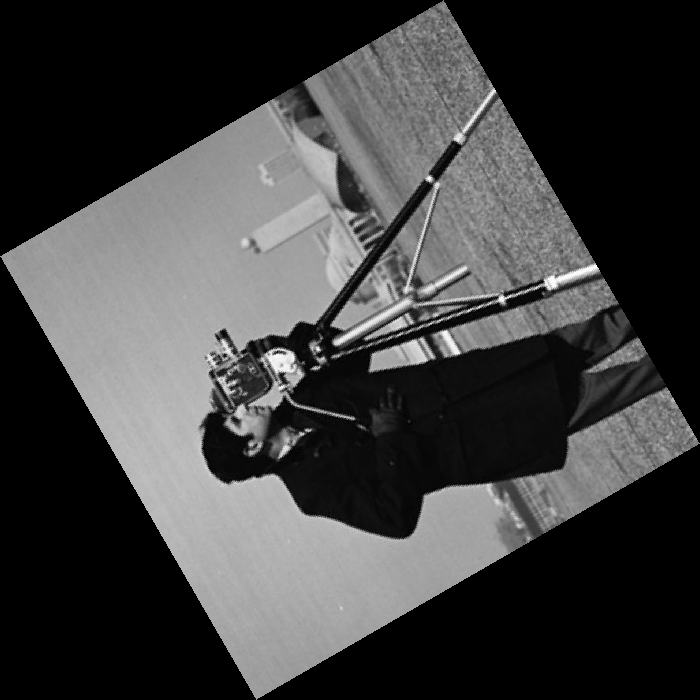

In [15]:
# ── 2. Rotate 120 degrees ──────────────
# expand=True grows the canvas so no corners are clipped;
# fillcolor=0 paints the exposed background black.
rotated_img = img.rotate(120, expand=True, fillcolor=0)

# Save the rotated image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size: ", rotated_img.size)
rotated_img


### 3. Shear

In [16]:
# -- c. Get the image dimensions ────────────
width, height = img.size
print("Image dimensions (w, h):", (width, height))


Image dimensions (w, h): (512, 512)


In [17]:
# -- d. define the shear matrix ──────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image
# slants — start with 0.5 then experiment.
shear_factor = 0.5

# X-axis shear: each row shifts sideways in proportion to its y-coordinate.
shx = shear_factor   # horizontal shear coefficient
shy = 0.0            # 0 -> no vertical shear (set shx=0, shy=factor for Y-axis)


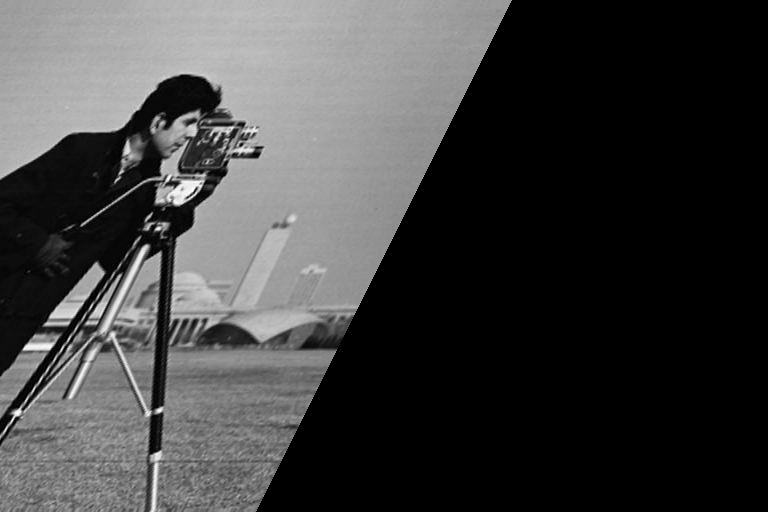

In [18]:
# -- e. Apply the shear transformation to the image ──────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

# Grow the canvas so the slanted image is not clipped.
new_width  = width  + int(abs(shx) * height)
new_height = height + int(abs(shy) * width)

sheared_img = img.transform(
    (new_width, new_height),
    Image.AFFINE,
    (1, shx, 0,
     shy, 1, 0),
    resample=Image.BICUBIC,
    fillcolor=0,
)
sheared_img


In [19]:
# -- f. Save the sheared image (The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size: ", sheared_img.size)


Original size: (512, 512)
Sheared size:  (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

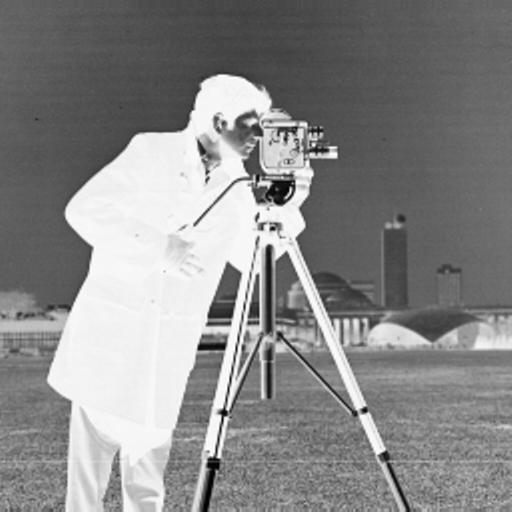

In [20]:

# ── 1. Negative ─────────────────────
# Method 1: NumPy array manipulation
# s = L - 1 - r,  with L = 256 levels  ->  s = 255 - r
arr = np.array(img)
negative_arr = 255 - arr

negative_img = Image.fromarray(negative_arr.astype(np.uint8))
negative_img.save("task2_1_negative_numpy.jpg")
negative_img


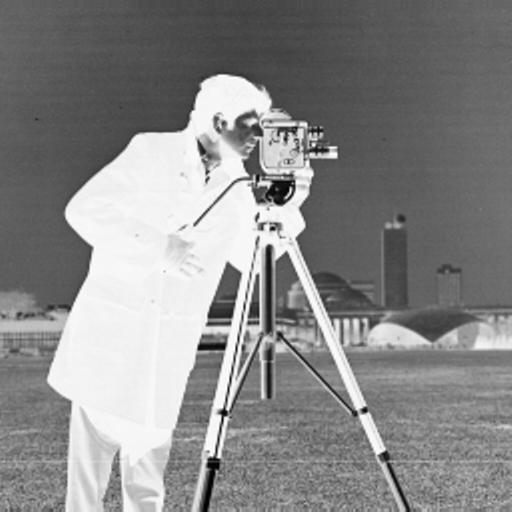

In [21]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(img)
negative_img2.save("task2_1_negative_imageops.jpg")
negative_img2


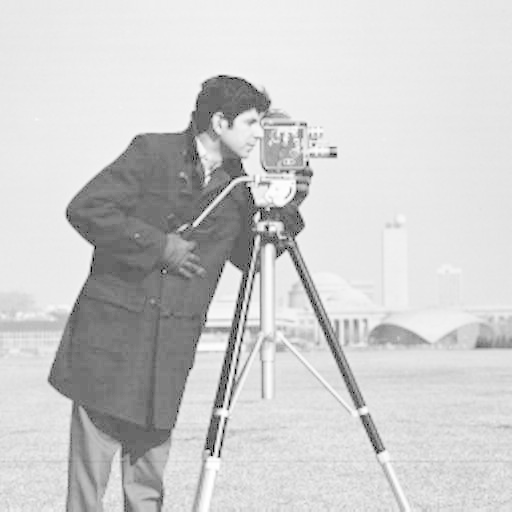

In [22]:
# ── 2. Log transformation ────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

# Use float so that (1 + r) never overflows uint8 (255 + 1 would wrap to 0 -> log(0)).
arr = np.array(img, dtype=np.float64)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)
log_img = Image.fromarray(np.uint8(log_transformed_arr))
log_img.save("task2_2_log.jpg")
log_img


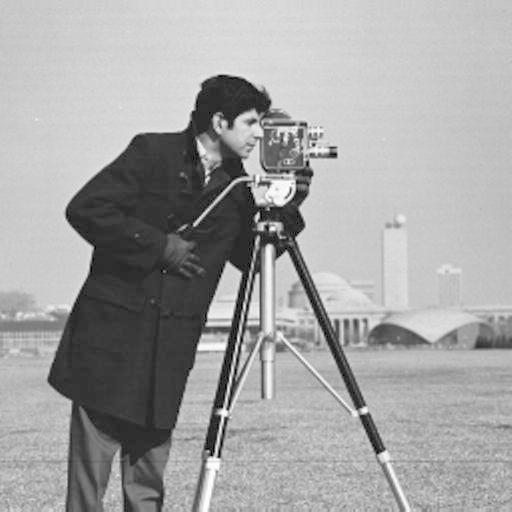

In [23]:

# ── 3. Power-law / Gamma correction ─────────
# s = c · r^gamma, computed on intensities normalised to [0, 1]
arr = np.array(img, dtype=np.float64) / 255.0

gamma = 0.5   # gamma < 1 brightens the image; gamma > 1 darkens it
c = 1.0

gamma_arr = c * np.power(arr, gamma)
gamma_img = Image.fromarray(np.uint8(gamma_arr * 255))
gamma_img.save("task2_3_gamma.jpg")
gamma_img


Gamma values (left -> right): [0.3, 0.5, 1.0, 2.0, 3.0]
(< 1 brightens, = 1 unchanged, > 1 darkens)


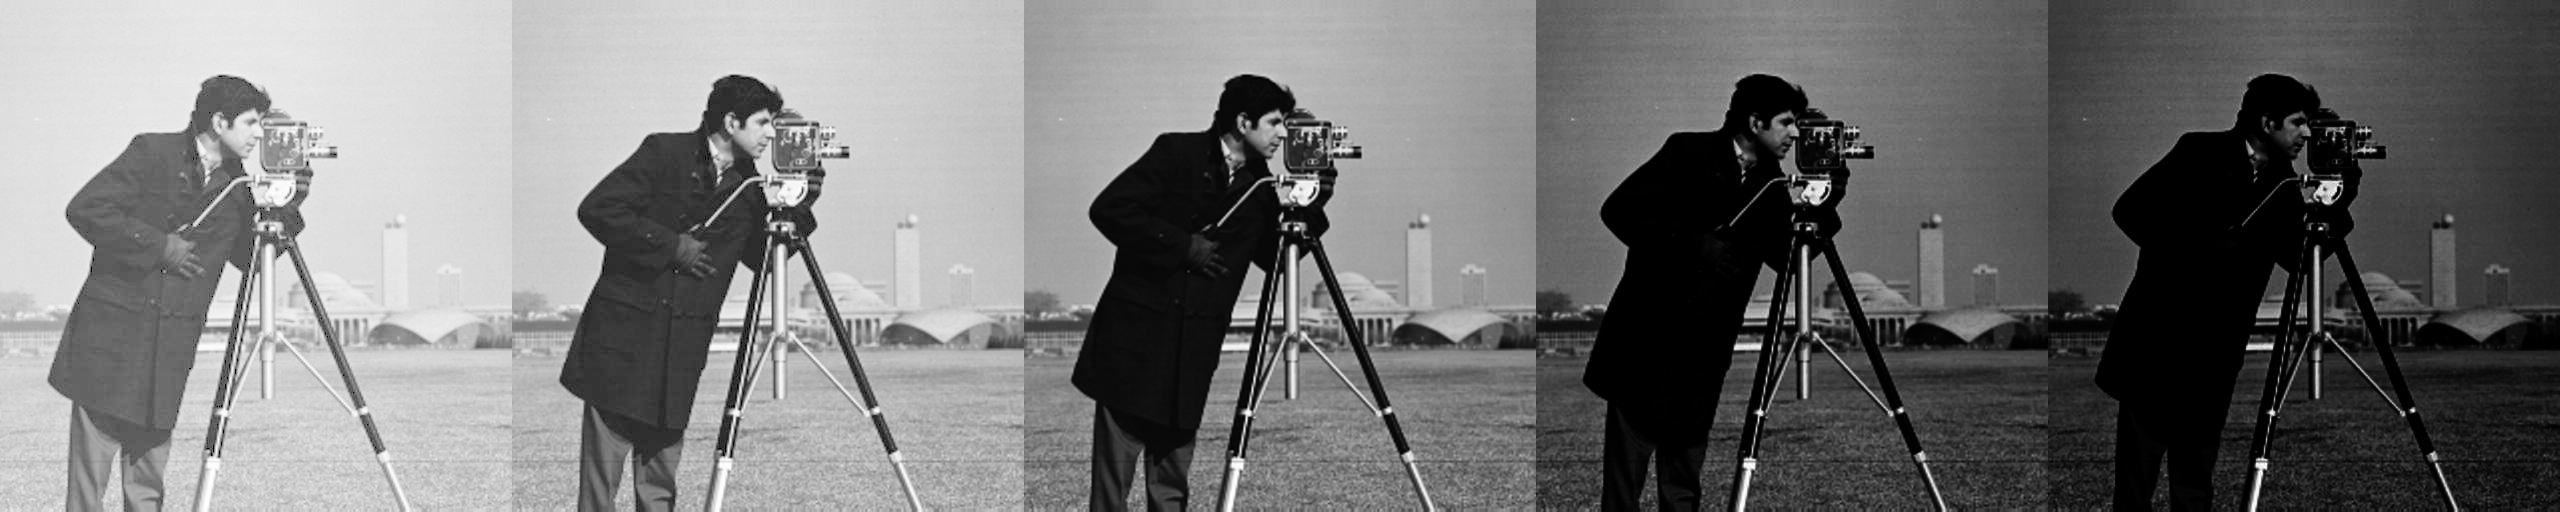

In [24]:
# Experiment: compare several gamma values side by side
gammas = [0.3, 0.5, 1.0, 2.0, 3.0]
base = np.array(img, dtype=np.float64) / 255.0

w, h = img.size
montage = Image.new("L", (w * len(gammas), h))
for k, g in enumerate(gammas):
    out = np.uint8(np.power(base, g) * 255)
    montage.paste(Image.fromarray(out), (k * w, 0))

montage.save("task2_3_gamma_compare.jpg")
print("Gamma values (left -> right):", gammas)
print("(< 1 brightens, = 1 unchanged, > 1 darkens)")
montage
